<a href="https://colab.research.google.com/github/iqbalkhanmahar271-star/ML-Lab7/blob/main/Lab_7_(Iqbal_AHmed_24F_Ai_208).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install required libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn

Step 1 — Libraries

pandas: to read and handle the dataset
numpy: for numerical calculations
matplotlib: to create graphs
seaborn: to create statistical graphs and heatmaps
train_test_split: to divide the data into training and testing sets
StandardScaler: to bring features to the same scale
SimpleImputer: to handle missing values
LinearRegression: to predict final marks
LogisticRegression: to predict Pass/Fail
Regression metrics: to check the performance of marks prediction
Classification metrics: to check the performance of Pass/Fail prediction
zipfile: to open the ZIP dataset
requests: to download the dataset from the internet
io: to handle the downloaded data in memory

In [3]:
# Step 1 — Libraries

# pandas: to read and handle the dataset
import pandas as pd

# numpy: for numerical calculations
import numpy as np

# matplotlib: to create graphs
import matplotlib.pyplot as plt

# seaborn: to create statistical graphs and heatmaps
import seaborn as sns

# train_test_split: to divide the data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler: to bring features to the same scale
from sklearn.preprocessing import StandardScaler

# SimpleImputer: to handle missing values
from sklearn.impute import SimpleImputer

# LinearRegression: to predict final marks
from sklearn.linear_model import LinearRegression

# LogisticRegression: to predict Pass/Fail
from sklearn.linear_model import LogisticRegression

# Regression metrics: to check the performance of marks prediction
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Classification metrics: to check the performance of Pass/Fail prediction
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# zipfile: to open the ZIP dataset
import zipfile

# requests: to download the dataset from the internet
import requests

# io: to handle the downloaded data in memory
import io

**Step 2 — Download Dataset**
Purpose:

UCI Student Performance dataset: to get student academic data for the project

requests: to download the dataset from the internet

zipfile: to open the downloaded ZIP file

io: to handle the downloaded file in memory

pandas: to read the student-mat.csv file into a DataFrame

In [4]:
# Step 2 — Download Dataset

# UCI Student Performance dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"

# Download the dataset from the internet
response = requests.get(url)

# Open the downloaded ZIP file
with zipfile.ZipFile(io.BytesIO(response.content)) as z:

    # Display the files available inside the ZIP file
    print("Files in dataset:")
    print(z.namelist())

    # Open the mathematics student dataset
    with z.open("student-mat.csv") as file:

        # Read the CSV file using pandas
        df = pd.read_csv(file, sep=";")

print("Dataset loaded successfully!")

Files in dataset:
['student-mat.csv', 'student-por.csv', 'student-merge.R', 'student.txt']
Dataset loaded successfully!


**Step 3 — Check the Dataset**
Purpose:

df.head(): to view the first 5 rows of the dataset

df.shape: to check the number of rows and columns

df.info(): to check the dataset structure, data types, and missing values

In [5]:
# Step 3 — Check the Dataset

# Display the first 5 rows of the dataset
print("First 5 rows:")
display(df.head())

# Display the number of rows and columns
print("\nDataset shape:")
print(df.shape)

# Display information about columns, data types, and missing values
print("\nDataset information:")
df.info()

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Dataset shape:
(395, 33)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nu

**Step 4 — Select Important Features**
Purpose:

features: to select the important columns that will be used for prediction

studytime: to use weekly study time as an input feature

absences: to use the number of absences as an input feature

G1: to use the first period grade as an input feature

G2: to use the second period grade as an input feature

G3: to use the final grade as the target/output

In [6]:
# Step 4 — Select Important Features

# Select important features for the prediction
features = [
    "studytime",
    "absences",
    "G1",
    "G2"
]

# Select G3 as the target variable
target = "G3"

# Store the selected features in X
X = df[features]

# Store the target variable in y
y = df[target]

# Display the selected features
print("Selected Features:")
display(X.head())

# Display the target variable
print("\nTarget Variable:")
display(y.head())

Selected Features:


,studytime,absences,G1,G2
0,2,6,5,6
1,2,4,5,5
2,2,10,7,8
3,3,2,15,14
4,2,4,6,10



Target Variable:


,G3
0,6
1,6
2,10
3,15
4,10


**Step 5 — Check Missing Values**
Purpose:

isnull(): to find missing values in the dataset

sum(): to count the total number of missing values in each column

We check both input features (X) and the target variable (y).

In [7]:
# Step 5 — Check Missing Values

# Check missing values in the selected features
print("Missing values in features:")
print(X.isnull().sum())

# Check missing values in the target variable
print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
studytime    0
absences     0
G1           0
G2           0
dtype: int64

Missing values in target:
0


**Step 6 — Train-Test Split**
Purpose:

train_test_split: to divide the dataset into training and testing data

Training data: used to train the machine learning model

Testing data: used to check how well the trained model performs on new data

test_size=0.20: 20% data is used for testing and 80% for training

random_state=42: to get the same split every time we run the code

In [8]:
# Step 6 — Train-Test Split

# Divide the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the number of training samples
print("Training samples:", len(X_train))

# Display the number of testing samples
print("Testing samples:", len(X_test))

Training samples: 316
Testing samples: 79


**Step 7 — Handle Missing Values**
Purpose:

SimpleImputer: to handle missing values in the dataset

strategy="median": to replace missing values with the median value of that column

fit_transform(): to learn the median from training data and fill missing values

transform(): to apply the same learned values to testing data

In [9]:
# Step 7 — Handle Missing Values

# Create an imputer to handle missing values using the median
imputer = SimpleImputer(strategy="median")

# Fit the imputer on training data and fill missing values
X_train_imputed = imputer.fit_transform(X_train)

# Apply the same imputer to testing data
X_test_imputed = imputer.transform(X_test)

print("Missing values handled successfully!")

Missing values handled successfully!


**Step 8 — Feature Scaling**
Purpose:

StandardScaler: to bring all features to a similar scale.

For example, absences can have larger values than studytime. Scaling helps the machine learning model work with the features more effectively.

fit_transform(): to learn the scaling values from training data and transform it.

transform(): to apply the same scaling to testing data.

In [10]:
# Step 8 — Feature Scaling

# Create a StandardScaler to scale the features
scaler = StandardScaler()

# Fit the scaler on training data and scale it
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Apply the same scaler to testing data
X_test_scaled = scaler.transform(X_test_imputed)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


**Step 9 — Linear Regression Model**
Purpose:

LinearRegression: to predict the student's final grade (G3) using:

studytime
absences
G1
G2

fit(): to train the model using the training data.

predict(): to predict final grades using the testing data.

In [11]:
# Step 9 — Linear Regression Model

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train_scaled, y_train)

# Predict final grades using the testing data
y_pred = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


**Step 10 — Evaluate Linear Regression Model**
Purpose:

MAE: to calculate the average absolute prediction error.

MSE: to calculate the average squared prediction error.

RMSE: to measure the prediction error and give more importance to larger errors.

R²: to measure how well the model explains the target values.

In [12]:
# Step 10 — Evaluate Linear Regression Model

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

# Display the results
print("================================")
print("LINEAR REGRESSION RESULTS")
print("================================")

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 2))

LINEAR REGRESSION RESULTS
MAE : 1.31
MSE : 4.18
RMSE: 2.04
R²  : 0.8


**Step 11 — Create Pass/Fail Target**
Purpose:

np.where(): to create a new Pass/Fail column based on the final grade.

G3 >= 10 → Pass (1)
G3 < 10 → Fail (0)

value_counts(): to count how many students are Pass and Fail.

In [13]:
# Step 11 — Create Pass/Fail Target

# Create a new column for Pass/Fail result
# 1 means Pass and 0 means Fail
df["pass_fail"] = np.where(
    df["G3"] >= 10,
    1,
    0
)

# Count the number of Pass and Fail students
print("Pass/Fail Distribution:")
print(df["pass_fail"].value_counts())

Pass/Fail Distribution:
pass_fail
1    265
0    130
Name: count, dtype: int64


**Step 12 — Prepare Data for Logistic Regression**
Purpose:

LogisticRegression: we will use it to predict whether a student will Pass or Fail.

X_class: contains the input features.

y_class: contains the Pass/Fail result.

train_test_split: divides the classification data into training and testing sets.

stratify: keeps the Pass/Fail ratio similar in training and testing data

In [14]:
# Step 12 — Prepare Data for Logistic Regression

# Select the same features for classification
X_class = df[features]

# Select Pass/Fail as the target variable
y_class = df["pass_fail"]

# Handle missing values
X_class_imputed = imputer.fit_transform(X_class)

# Scale the classification features
X_class_scaled = scaler.fit_transform(X_class_imputed)

# Divide the classification data into training and testing sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_scaled,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Classification data prepared successfully!")

Classification data prepared successfully!


**Step 13 — Logistic Regression Model**
Purpose:

LogisticRegression: to predict whether a student will Pass or Fail.

fit(): to train the model using the training data.

predict(): to predict Pass/Fail using the testing data.

max_iter=1000: gives the model enough iterations to complete training.

In [15]:
# Step 13 — Logistic Regression Model

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model using the training data
logistic_model.fit(
    X_train_c,
    y_train_c
)

# Predict Pass or Fail using the testing data
y_pred_class = logistic_model.predict(X_test_c)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Step 14 — Evaluate Classification Model
Purpose:

accuracy_score: to check the percentage of correct predictions.

precision_score: to check how many predicted Pass students were actually Pass.

recall_score: to check how many actual Pass students were correctly predicted.

classification_report: to show a detailed classification performance report.

In [16]:
# Step 14 — Evaluate Classification Model

# Calculate accuracy
accuracy = accuracy_score(
    y_test_c,
    y_pred_class
)

# Calculate precision
precision = precision_score(
    y_test_c,
    y_pred_class,
    zero_division=0
)

# Calculate recall
recall = recall_score(
    y_test_c,
    y_pred_class,
    zero_division=0
)

# Display the results
print("================================")
print("LOGISTIC REGRESSION RESULTS")
print("================================")

print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))

# Display the detailed classification report
print("\nClassification Report:")

print(
    classification_report(
        y_test_c,
        y_pred_class,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)

LOGISTIC REGRESSION RESULTS
Accuracy : 0.89
Precision: 0.94
Recall   : 0.89

Classification Report:
              precision    recall  f1-score   support

        Fail       0.79      0.88      0.84        26
        Pass       0.94      0.89      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.89      0.87        79
weighted avg       0.89      0.89      0.89        79



**Step 15 — Confusion Matrix**
Purpose:

confusion_matrix: to compare the actual Pass/Fail results with the predicted Pass/Fail results.

seaborn.heatmap: to display the confusion matrix as a visual heatmap.

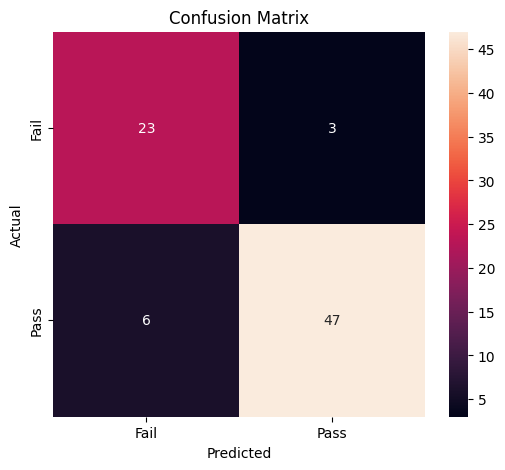

In [17]:
# Step 15 — Confusion Matrix

# Calculate the confusion matrix
cm = confusion_matrix(
    y_test_c,
    y_pred_class
)

# Create a figure for the confusion matrix
plt.figure(figsize=(6, 5))

# Display the confusion matrix as a heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

# Add labels and title
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Display the graph
plt.show()

**Step 16 — Correlation Heatmap**
Purpose:

corr(): finds the relationship between numerical variables.
sns.heatmap(): shows the correlation using a visual heatmap.
A value near +1 means strong positive relationship.
A value near -1 means strong negative relationship.
A value near 0 means weak relationship.

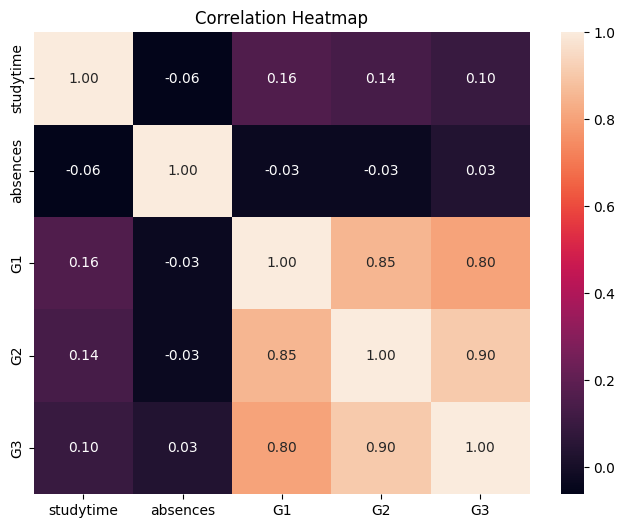

In [18]:
# Step 16 — Correlation Heatmap

# Select important numerical columns
correlation_data = df[
    ["studytime", "absences", "G1", "G2", "G3"]
]

# Calculate correlation between the columns
correlation_matrix = correlation_data.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

# Add title
plt.title("Correlation Heatmap")

# Display the graph
plt.show()

**Step 17 — Feature Distributions**
Purpose:

hist(): shows the distribution of the selected features.
It helps us understand how values are spread.
We can see the distribution of study time, absences, G1 and G2.

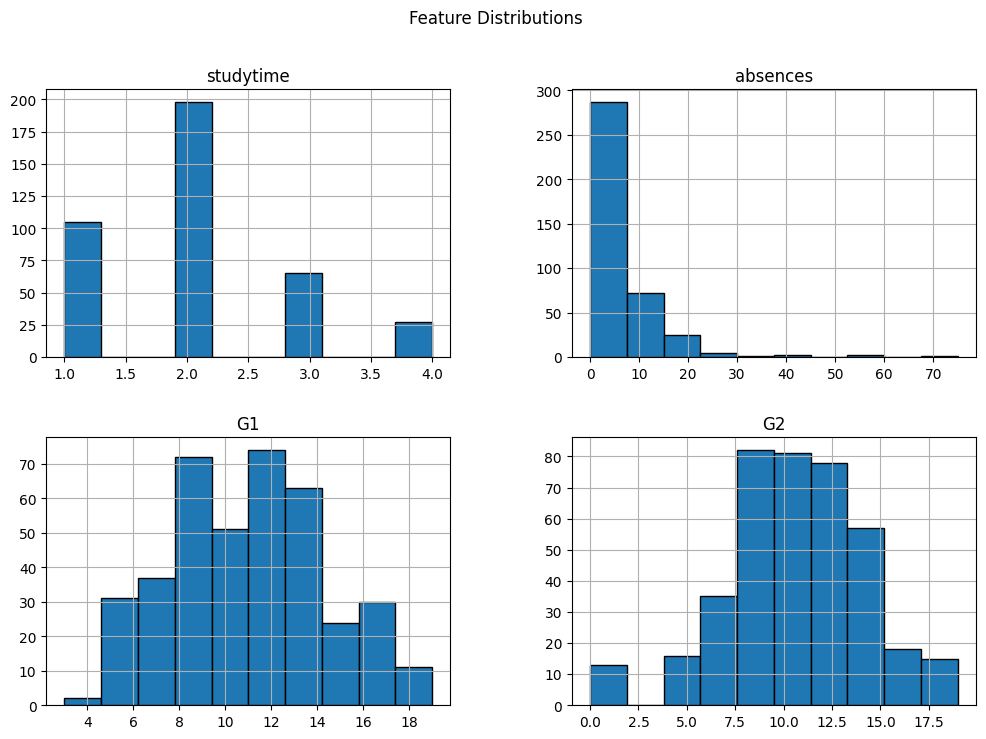

In [19]:
# Step 17 — Feature Distributions

# Display distributions of selected features
df[features].hist(
    figsize=(12, 8),
    edgecolor="black"
)

# Add title
plt.suptitle("Feature Distributions")

# Display the graphs
plt.show()

Step 18 — Pass/Fail Visualization

Purpose:

countplot(): shows the number of students in each category.
It helps us visually compare Pass and Fail students.

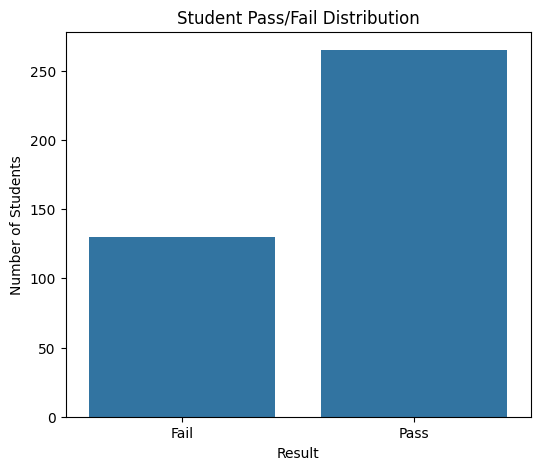

In [20]:
# Step 18 — Pass/Fail Visualization

# Create a graph showing Pass and Fail students
plt.figure(figsize=(6, 5))

sns.countplot(
    x="pass_fail",
    data=df
)

# Change 0 and 1 into Fail and Pass
plt.xticks(
    [0, 1],
    ["Fail", "Pass"]
)

# Add labels and title
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.title("Student Pass/Fail Distribution")

# Display the graph
plt.show()

Step 19 — New Student Prediction

Purpose:

input(): takes information from a new student.
DataFrame: creates data in the same format as our training data.
transform(): applies the same preprocessing.
predict(): predicts final marks and Pass/Fail.

In [21]:
# Step 19 — New Student Prediction

print("================================")
print("NEW STUDENT PREDICTION")
print("================================")

# Take information from a new student
studytime = float(input("Enter study time (1-4): "))
absences = float(input("Enter number of absences: "))
G1 = float(input("Enter first period grade G1 (0-20): "))
G2 = float(input("Enter second period grade G2 (0-20): "))

# Create a DataFrame for the new student
new_student = pd.DataFrame({
    "studytime": [studytime],
    "absences": [absences],
    "G1": [G1],
    "G2": [G2]
})

# Handle missing values
new_student_imputed = imputer.transform(new_student)

# Scale the new student's data
new_student_scaled = scaler.transform(
    new_student_imputed
)

# Predict final marks
predicted_marks = linear_model.predict(
    new_student_scaled
)[0]

# Predict Pass or Fail
predicted_class = logistic_model.predict(
    new_student_scaled
)[0]

# Display prediction result
print("\n================================")
print("PREDICTION RESULT")
print("================================")

print(
    "Predicted Final Marks:",
    round(predicted_marks, 2)
)

if predicted_class == 1:
    print("Predicted Result: PASS")
else:
    print("Predicted Result: FAIL")

NEW STUDENT PREDICTION
Enter study time (1-4): 3
Enter number of absences: 1
Enter first period grade G1 (0-20): 3
Enter second period grade G2 (0-20): 8

PREDICTION RESULT
Predicted Final Marks: 6.13
Predicted Result: FAIL


 **Conclusion**

In this lab, we used Machine Learning to predict student performance. We used the student dataset and selected features like study time, absences, G1, and G2 to predict the final grade. We used Linear Regression to predict the final marks and Logistic Regression to predict whether a student would pass or fail. We also handled missing values, scaled the data, and checked the performance of both models using different evaluation methods. The graphs helped us understand the data and the prediction results more clearly. Overall, this lab helped us understand how Machine Learning can be used in a simple real-life problem like predicting student performance.
